v9- 9/26/24'; added updated time-series importing logic to ensure congruence across different csripts.
10/10/24; added Late IA vs Early RS comparison for decoding (+ weight testing)
using new packaging logic develoepd ~ v7
v11- 10/29/24
-adding cross-stage out of distribution testing for decoding (e.g. train on IA Error vs RS Erorr, test on IA correct vs RS Correct)
v12- 11/11/24 running on 3,15,250, 0.01 abs spike detection params
v13- 11/14/24- running on gauss_smooth + 80% cutoff + temporal dedup, also deleting PCA save step as you are regenerating PC projection with new boostrap pulls in the plotting version of this
v15- 12/4/24- testing # of Early RS COrrect trials occuring b4 and after the Early RS Error trials.



## Setup


In [1]:
%cd "G:\My Drive\Colab Notebooks\Function .py Storage"
%pip install -r requirements.txt
import sys, os
sys.path.append(os.path.abspath('MyDrive/Colab Notebooks/Function .py Storage'))
#run import modules 
from package_imports import png, np, matplotlib, plt, pd, sns, itertools, scipy, warnings, tqdm, sklearn, datetime
from custom_module_imports import * 
#import prebuilt modules
from scipy import stats
from sklearn import svm, metrics, model_selection
from sklearn.decomposition import PCA
from functools import partial
from joblib import Parallel, delayed 
import json
#import custom modules
from phase_enrichment_timeseries.phase_enrich_timeseries_decode import * #contains: resamp_mak e_class_obj, resample_combine_dict_of_activity_dfs
from taco_functions_module import TACO_table_feature_annotation_functions
%matplotlib inline

pd.set_option('mode.use_inf_as_na', False)
pd.set_option('future.no_silent_downcasting', True)
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},SKLEARN ver: {sklearn.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.get_option("mode.use_inf_as_na")
plt.style.use('paper_plot.mplstyle') ## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

#test local vs colab
local_use = True
if local_use:
    analysis_data_to_use = '10-Dec-2024'
    analysis_data_to_use_folder = '11-Dec-2024_event_fixed_stage_labels'
    datasets_location = f"G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/{analysis_data_to_use_folder} Dataset Source/"
    enriched_by_stage_path = f'main_datasets_complexTACO- neurons_activity by task phase_{analysis_data_to_use}.xls' #300 shuff, april 24 run
    post_activity_timeseries = datasets_location + f'post_outcome_main_datasets_neurons_trial activity timeseries data_{analysis_data_to_use}_timeseries.csv'
    timeseries_loc = datasets_location

print(datasets_location)
print(post_activity_timeseries)
os.getcwd()

G:\My Drive\Colab Notebooks\Function .py Storage


C:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]



matplotlib version: 3.7.0,sns version: 0.12.2,SKLEARN ver: 1.5.2
G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/11-Dec-2024_event_fixed_stage_labels Dataset Source/
G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/11-Dec-2024_event_fixed_stage_labels Dataset Source/post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv


C:\Users\13car\AppData\Local\Temp\ipykernel_8816\809369592.py:20: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', False)


'G:\\My Drive\\Colab Notebooks\\Function .py Storage'

## Import neural datasets + set parameters

In [2]:
# datasets_location = "/content/drive/MyDrive/Colab Notebooks/"# TACO_location = "Time-series activity datasets"
folder_loc = 'G:/My Drive/Colab Notebooks/Run Outputs/'
os.chdir(folder_loc)
#make figure storage
cwd = os.getcwd()
print(f" CWD: {cwd}")
record_metadata_tag = False #this is if you are going to append the folder name for these figures, with information about the processing
metadata_tag = ""
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
folder_name =folder_loc+  f"figure_5_prep_mid_decoding figures_"+ date_tag + metadata_tag + "/"
make_folder(folder_name)
os.chdir(folder_name)
subfolder_names= make_figtype_subfolders(folder_name)
#save hyperparameters: 
# open a file for writing
with open('hyper_param_dict.json', 'w') as f:
    # write the dictionary to the file in JSON format
    json.dump(hyper_param_dict, f)
## save metatdata of current run
f = open("latest_figure_5_decode_setup_run_source_data.txt", "w")
f.write(f"latest_figure_5_decode_setup_source_data enrichment source: {enriched_by_stage_path}. Activity time-series record used : {post_activity_timeseries}")
f.close()
os.getcwd()

 CWD: G:\My Drive\Colab Notebooks\Run Outputs
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_prep_mid_decoding figures_28_Jan_2025/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_prep_mid_decoding figures_28_Jan_2025/svg_plots/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_prep_mid_decoding figures_28_Jan_2025/pdf_plots/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_prep_mid_decoding figures_28_Jan_2025/png_plots/' has been created.


'G:\\My Drive\\Colab Notebooks\\Run Outputs\\figure_5_prep_mid_decoding figures_28_Jan_2025'

#### if reading unbinned data- bin

In [3]:
hyper_param_dict

{'drop_low_responders': False,
 'drop_cells_active_in_1_trial': False,
 'window_to_bin': 5,
 'bin_size': 0.25,
 'n_sec_to_rotate': 0,
 'n_pre_bin_to_drop': 8,
 'n_post_end_bin_to_drop': 0,
 'normalize_data': True,
 'drop_subj_w_1_stage_trial': False,
 'data_type': 'event_rate',
 'trial_tseries_save_name': 'single_trial_post_neuron_timeseries_w_enrichment_11-Dec-2024_.csv'}

In [4]:
#declare loc/names of files to read
os.chdir(timeseries_loc)#navigate to dataset folders
print(timeseries_loc)
single_trial_tseries_w_enrich = get_normed_trial_tseries(enriched_by_stage_path,post_activity_timeseries, hyper_param_dict)
stage_names = sorted(single_trial_tseries_w_enrich [stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(single_trial_tseries_w_enrich, " to ")
print(f"Timebins bins: {numeric_col}")
single_trial_tseries_w_enrich.head()

G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/11-Dec-2024_event_fixed_stage_labels Dataset Source/
  Var1_4      Var1_5 Var1_6
0  False  bimodality      1
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
          name  mean activity
0  13_4_WT_RS1       0.024520
1  13_6_WT_RS1       0.023264
2  14_2_WT_RS1       0.021974
3   5_3_WT_RS1       0.017931
4   6_2_WT_RS1       0.015547
5   7_2_WT_RS1       0.012062
6   7_4_WT_RS1       0.015499
7   7_5_WT_RS1       0.029513
Dropping 0 bins from end: []
Dropping 8 bins from start: Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s'],
      dtype='object')
Timebins bins: Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.000000,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.000000,False
4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0,0.193333,True
5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0,0.000000,False


In [5]:

stage_names = sorted(single_trial_tseries_w_enrich[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
# numeric_col = get_numeric_cols_timeseries(single_trial_tseries_w_enrich, " to ")
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(single_trial_tseries_w_enrich,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col)
unit_mean_tseries['mean_rate'] = unit_mean_tseries[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(single_trial_tseries_w_enrich) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['unique_ID'].nunique()
subject_stage_info_df.tail()

,name,geno_day,task_phase_vec,unique_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",34,179,"[3, 5]",2,"[False, False]"
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",9,179,"[17, 19, 21]",3,"[True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",9,179,"[18, 20]",2,"[True, True]"
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-9, 9_3_HET_RS3-25, 9_3_HET_RS3-31...",15,179,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130]",2,179,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### Import Single Trial time-series dataset with enrichment information

#### Set parameter name/info for reference


In [6]:
#set unit name and type of data
data_type = 'post_outcome_activity'
units = 'cells'
unit_ID_col=  "unique_ID"
#phase related information
phase_names = single_trial_tseries_w_enrich.task_phase_vec.unique()
#determine comparisosn to be decoding on
class_comparisons = [
    [phase_names[0], phase_names[1]], #early IA corr vs. early IA err
    [phase_names[0], phase_names[3]],#- early IA corr vs. early RS corr
    [phase_names[1], phase_names[4]],#  - early IA err vs.l early RS err
    [phase_names[3], phase_names[4]],#- early RS corr vs. early RS err
    [phase_names[2], phase_names[5]],#- late IA vs. late RS
    [phase_names[0], phase_names[2]],#- early IA corr vs. late IA
    [phase_names[3], phase_names[5]],#- early RS corr vs. late RS
    [phase_names[2], phase_names[3]],#late IA vs early RS corr
                     ]
print(numeric_col)
print(phase_names)
class_comparisons

Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 1

[['Early_IA_Correct', 'Early_IA_Error'],
 ['Early_IA_Correct', 'Early_RS_Correct'],
 ['Early_IA_Error', 'Early_RS_Error'],
 ['Early_RS_Correct', 'Early_RS_Error'],
 ['Late_IA', 'Late_RS'],
 ['Early_IA_Correct', 'Late_IA'],
 ['Early_RS_Correct', 'Late_RS'],
 ['Late_IA', 'Early_RS_Correct']]

## Create summary viz of enriched units info and frame data


In [7]:
print(folder_name)


G:/My Drive/Colab Notebooks/Run Outputs/figure_5_prep_mid_decoding figures_28_Jan_2025/


G:\My Drive\Colab Notebooks\Function .py Storage\phase_enrichment_timeseries\phase_enrich_timeseries_decode.py:339: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  unit_count_fig.subplots_adjust(top = 0.9);


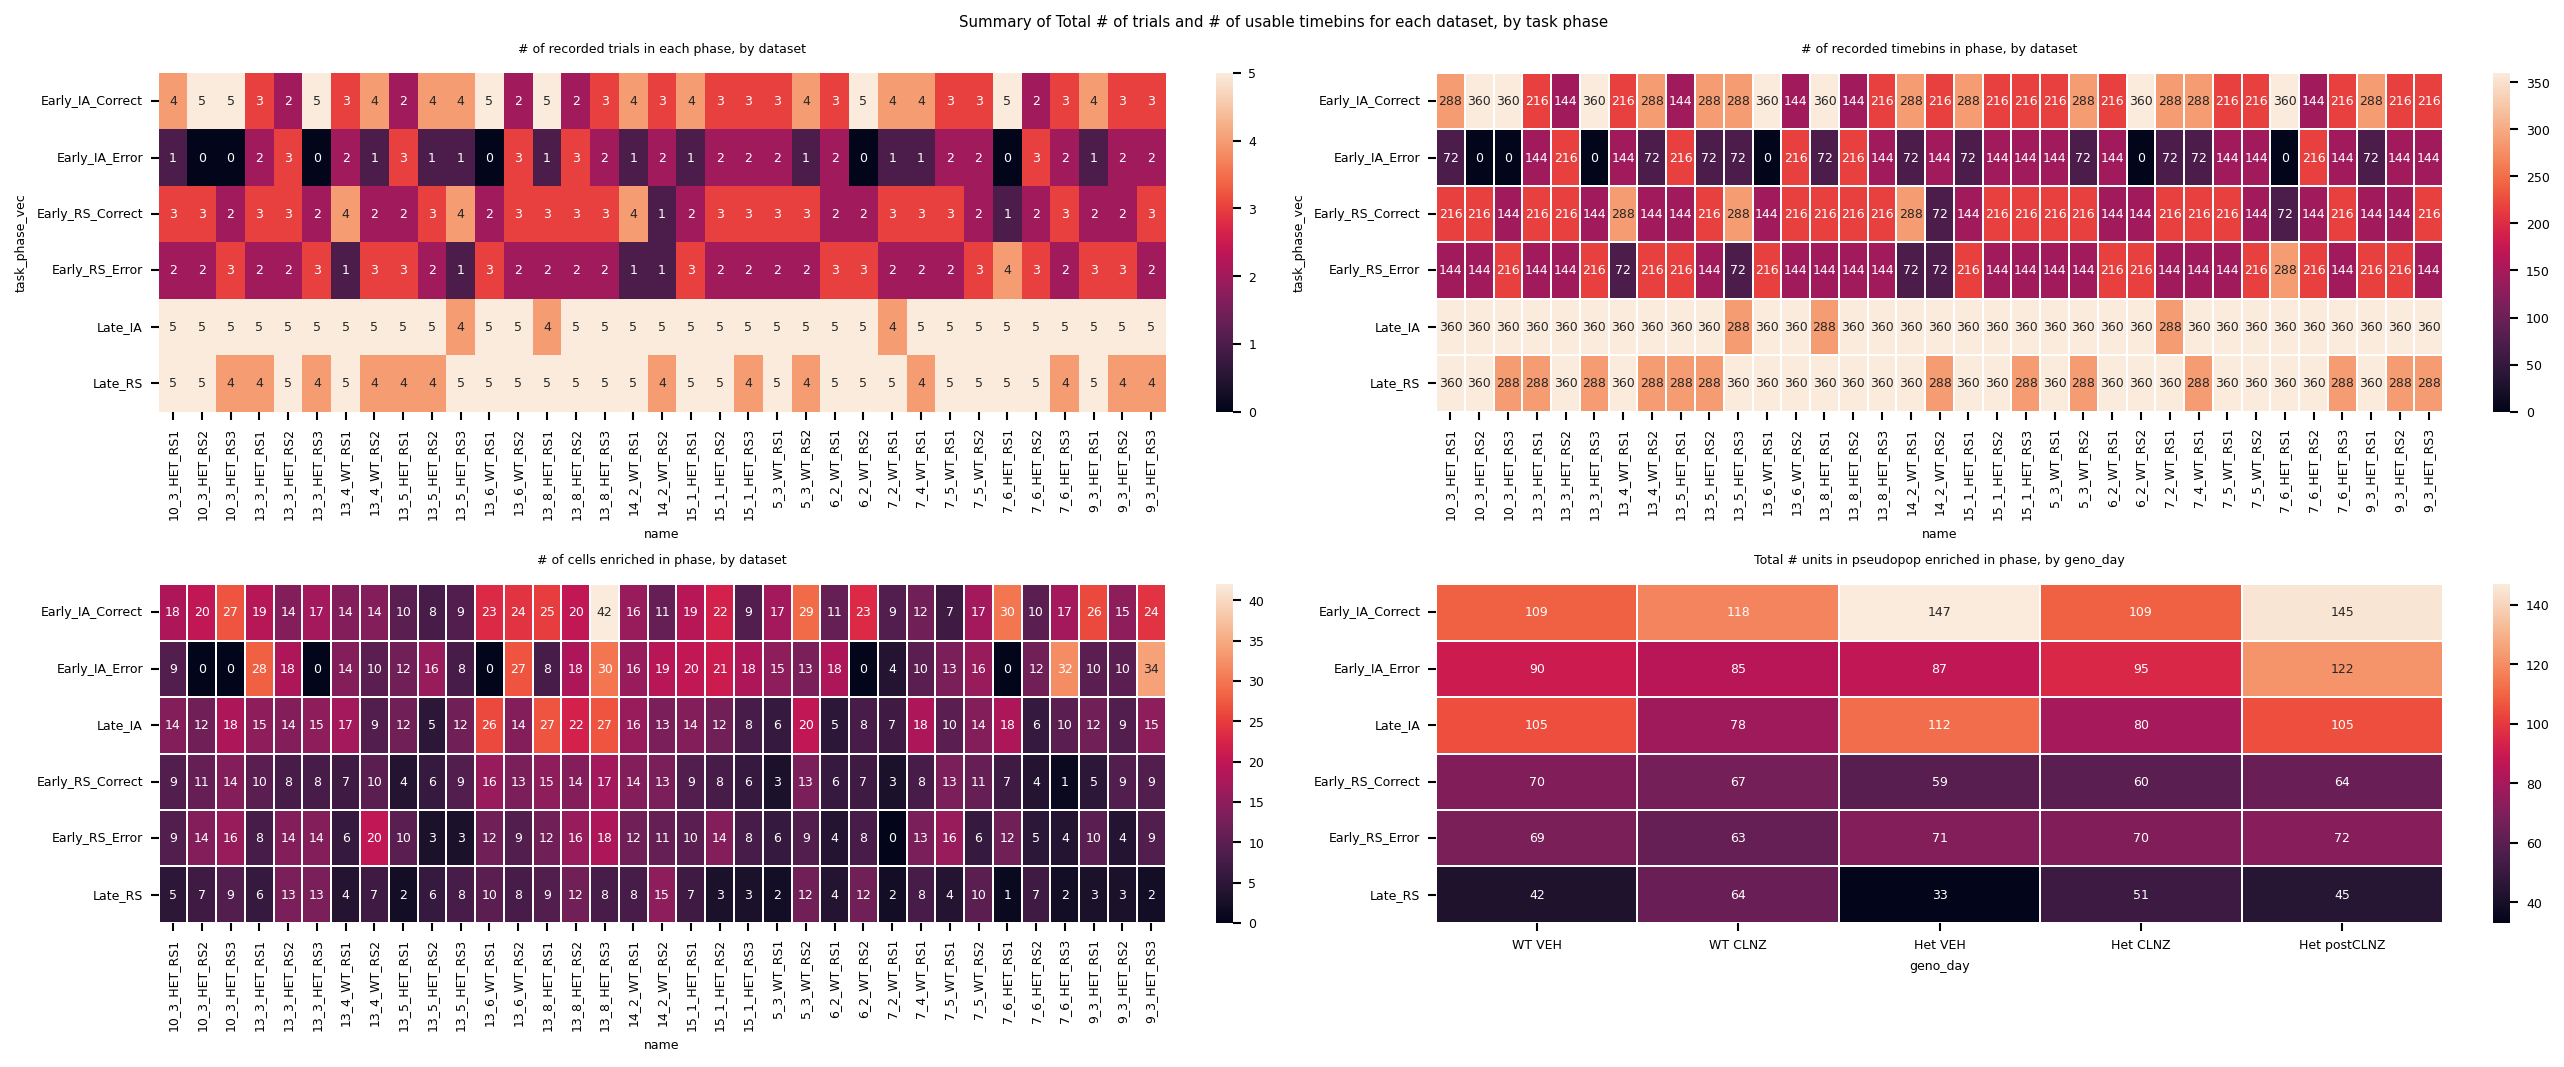

In [8]:
#gather trial types
trial_type_by_subj = get_num_trials_by_type_in_subject(single_trial_tseries_w_enrich, 'task_phase_vec').fillna(0);
trial_type_by_subj[phase_names] = trial_type_by_subj[phase_names].astype(int)
neuron_enrichment =  single_trial_tseries_w_enrich.groupby(['name', 'geno_day', 'neuron_ID'])[phase_names].mean().reset_index()
phase_enrichment_by_subj = neuron_enrichment[list(phase_names) + ['name', 'geno_day']].groupby(by = ['name', 'geno_day']).sum().reset_index()

#make figures
unit_count_fig, axs = plot_unit_enrich_by_phase_summary((17,7), trial_type_by_subj,phase_enrichment_by_subj,geno_order_w_WT_CLNZ, phase_names,numeric_col)
#save as a fig
pdf_name = f"Enrichment of {units} and # of samples per phase"
save_fig_as_filetype_list(unit_count_fig, pdf_name , subfolder_names, ['pdf', 'png'])

### New Pseudopop generation by resampling cell activity time-series

#### Get all time-series corresponding to dataset N

In [9]:
single_trial_tseries_w_enrich= single_trial_tseries_w_enrich.assign(**{'unique_ID':single_trial_tseries_w_enrich.name.str.cat(
    single_trial_tseries_w_enrich.neuron_ID.astype(str), sep = "-"), 'any_enrichment':  single_trial_tseries_w_enrich[phase_names].sum(axis = 1)})

trial_list_by_dataset = get_trial_num_in_phase_by_dataset( single_trial_tseries_w_enrich)
##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
enrich_unit_ID_by_name_df =get_ID_enriched_units_by_phase(single_trial_tseries_w_enrich, 'unique_ID', 'enriched_in_phase')
dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['name'].unique().reset_index()
#add unique identifier that's (dataset_name + neuron_ID) to retain neuron ID info

In [10]:
enrich_unit_ID_by_name_df.tail()

,name,geno_day,task_phase_vec,unique_ID,num_enriched_units
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",34
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",9
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",9
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-9, 9_3_HET_RS3-25, 9_3_HET_RS3-31...",15
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130]",2


## Find accuracy of decoding in distribution / record results 

#### package all real enrichewd cell activations for future use

In [11]:
## make real dataset storage
dataset_name_by_geno_day
phase_enrichment_by_subj
class_matrix_store  = make_dataset_matrix_store_only(phase_names, single_trial_tseries_w_enrich,unit_ID_col,enrich_unit_ID_by_name_df, numeric_col, trial_list_by_dataset,dataset_name_by_geno_day,phase_enrichment_by_subj)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


### Run pseudopopulation loop

In [12]:
def get_test_precision_recall_acc(test_set_data, test_set_labels, trained_model):
#TO- given model already trained on test set, create prediction vec, then calculate precision and recall
    prediction_vec =trained_model.predict(test_set_data)
    true_positive_vec = test_set_labels*prediction_vec
    ## get score metrics
    precision = (1+np.sum(true_positive_vec))/(1+ np.sum(prediction_vec)) #precision = % of predicted 1 / true 1
    recall = (1+ np.sum(true_positive_vec))/ (1+np.sum(test_set_labels)) #recall =  % of predicted 1/ all 1
    acc = np.mean(prediction_vec == test_set_labels)
    return precision, recall,acc

In [13]:
# ##new subfunct-

# def make_class_label_vector(class_matrix, class_val):
#     class_labels = np.repeat(class_val, class_matrix.shape[1])
#     return class_labels

# def resamp_make_class_obj(class_matrix_store,n_resample, ensemble_name, class_name, class_val, geno_day_curr):
#     """TO: given a matrix of data where col = frames, row = units, and N times to resmaple from this,
#     generate a new matrix of combined activity data, resampled N times from the originating data"""
#     local_rng = np.random.default_rng() #create a Generator instance with default_rng
#     class_matrix = resample_combine_dict_of_activity_dfs(class_matrix_store[ensemble_name][class_name][geno_day_curr], n_resample,local_rng)
#     class_labels = make_class_label_vector(class_matrix, class_val)
#     class_obj = {'matrix': class_matrix, 'labels': class_labels}#, 'source_index': class_idx}
#     return class_obj

# def fast_pack_data_local(class_0_mat, class_1_mat,class_0_value, class_1_value):
#     #TO- given 2 objects containg ['matrix', 'labels'] fields, join each field's content together and export (Transposing for easier use later)
#     #returns numpy array which = transpose of concat. data matrix and labels
#     concat_matrix = class_0_mat.join(class_1_mat, how = 'inner', lsuffix = '_c0', rsuffix = '_c1') #use inner to avoid having missing cells in a condition if dataset missing that phase's trials
#     #outer keeps empty cells from another dataset, which is OBVIOUS clue if condition 1 is e.g. missing early IA error cells from some datasets
#     class_label_0 = make_class_label_vector(class_0_mat, class_0_value)
#     class_label_1 = make_class_label_vector(class_1_mat, class_1_value)
#     concat_labels =  np.concatenate([class_label_0,class_label_1 ]) #concat class 0 and 1 label vector and optionally add as final row of matrix (to shuffle it exactly the same)
#     return concat_matrix, concat_labels #transpose matrix and labels to avoid having to ranspose later

# def pack_train_test_data_local(class_0_obj, class_1_obj,class_0_value, class_1_value):
#     '''#TO- given 2 objects containg ['matrix', 'labels'] fields, join each field's content together and export (Transposing for easier use later) '''
#     #returns numpy array which = transpose of concat. data matrix and labels
#     concat_matrix = class_0_obj['matrix'].join(class_1_obj['matrix'], how = 'inner', lsuffix = '_c0', rsuffix = '_c1') #use inner to avoid having missing cells in a condition if dataset missing that phase's trials
#     #outer keeps empty cells from another dataset, which is OBVIOUS clue if condition 1 is e.g. missing early IA error cells from some datasets
#     concat_labels =  np.concatenate([class_0_obj['labels'], class_1_obj['labels']]) #concat class 0 and 1 label vector and optionally add as final row of matrix (to shuffle it exactly the same)
#     return concat_matrix.T.values, concat_labels #transpose matrix and labels to avoid having to ranspose later


In [14]:
# #reample data
# def resample_into_class_matrix(class_matrix_store,n_resample, ensemble_name, class_name, geno_day_curr):
#     local_rng = np.random.default_rng() #create a Generator instance with default_rng
#     class_matrix = resample_combine_dict_of_activity_dfs(class_matrix_store[ensemble_name][class_name][geno_day_curr], n_resample,local_rng)
#     return class_matrix

# def resample_combine_dict_of_activity_dfs(dict_of_activity_dfs, num_resample,local_rng):
#     """TO: given a dict of activity matrices where rows = units, cols = frames and scalar N, resample it N times into a list.
#     Each list elem = activity from a diff subj (to allow for varying len datasets)"""
#     resampled_dict_list =[resample_unit_timeseries_df(d, num_resample,local_rng) for d in dict_of_activity_dfs.values()]
#     #NO LONGER RETURNS TUPLES 9/26/24/ #above returns list of tuples (resample df, resample IDs)
#     # resampled_df = pd.concat([e for e in resampled_dict_list], axis = 0)
#     resampled_df = pd.concat(resampled_dict_list, axis = 0)
#     return resampled_df

# def resample_unit_timeseries_df(input_timeseries_df, num_resample,local_rng):
#     #TO- retain original tseries index, but join to newly resample df
#     resample_matrix = resample_matrix_rows_w_replace(input_timeseries_df.values, num_resample, local_rng)
#     resample_unit_df = pd.DataFrame(data = resample_matrix, index = input_timeseries_df.index)
#     return resample_unit_df

# def resample_matrix_rows_w_replace(input_matrix, num_resample,local_rng):
#     """ returns resampled matrix, and indices used to generate resample. feed in pre-created resample """
#     num_units, array_cols = input_matrix.shape #get dims of input_matrix #assume that array_rows = num_units  you sample from in dataset
#     resample_idx = local_rng.choice(array_cols, size = (num_units,num_resample), replace = True) #output shape: (num_units,num_resample)
#     resampled_matrix = np.take_along_axis(input_matrix, resample_idx, axis=1) #axis = 1 means slices  in rows
#     #Take values from input mat by matching 1d index vals in data slices.
#     return resampled_matrix


#### experiment w subject level boostrap performance

In [34]:
#testd single cv fold, frpi between test and trani data
concat_labels = np.arange(1,1000)
k_folds = 1
cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =0.5)#Create CV object do leave one out split using minority class indices

if k_folds == 1:
    single_split= next(cv.split(np.zeros(len(concat_labels)), concat_labels))
    cv_iter_index = [[0, 1], [1,0]] #iter 1- use split 0 = train, split 1 = test| iter 2- split 1 = train, split 0 = test    
    for split_count, (test_index, train_index) in enumerate(cv_iter_index):
        test = single_split[test_index]
        train = single_split[train_index]
        


In [35]:
class_matrix_store

{'Early_IA_Correct': {'Early_IA_Correct': {'Het CLNZ': {'10_3_HET_RS2':                   -3.0s to -2.75s  -2.75s to -2.5s  -2.5s to -2.25s  \
    unique_ID                                                             
    10_3_HET_RS2-5                0.0              0.0              0.0   
    10_3_HET_RS2-10               0.0              0.0              0.0   
    10_3_HET_RS2-12               0.0              0.0              0.0   
    10_3_HET_RS2-21               0.0              1.0              0.4   
    10_3_HET_RS2-34               1.0              1.0              1.0   
    10_3_HET_RS2-44               0.0              0.0              0.0   
    10_3_HET_RS2-56               0.0              0.0              0.0   
    10_3_HET_RS2-60               0.0              0.0              0.4   
    10_3_HET_RS2-69               0.6              0.4              0.8   
    10_3_HET_RS2-90               1.0              1.0              1.0   
    10_3_HET_RS2-105            

In [53]:
for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1) 

In [54]:
#transform (unique ID) index into (subject, cell ID) multiindex
concat_matrix.index =pd.MultiIndex.from_tuples(concat_matrix.index.str.split('-').tolist())
mat_subj = concat_matrix.index.unique(level=0) #get unique value in level 0 of index
for subj_count, subj_name in enumerate(mat_subj): #iterate through subjects in current DF 
    subj_mat = concat_matrix.loc[mat_subj[0],:]

,0_c0,1_c0,2_c0,3_c0,4_c0,5_c0,6_c0,7_c0,8_c0,9_c0,...,390_c1,391_c1,392_c1,393_c1,394_c1,395_c1,396_c1,397_c1,398_c1,399_c1
50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
51,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#test single subject sampling 
# option 1- manually resample df
#option 2- normal concat matrix, but read index and CUT by unique ID prefix? 
input_timeseries_df = 
local_rng = np.random.default_rng() #create a Generator instance with default_rng
single_subj_resample = resample_unit_timeseries_df(input_timeseries_df, num_resample,local_rng)
single_subj_resample

In [77]:
def run_N_stage_decoder_single_subject(class_matrix_store,class_comparisons, num_resample, n_pseudopop_run_range):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    #declare variables for local use
    test_size = 0.5
    k_folds = 2
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    base_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    #transform (unique ID) index into (subject, cell ID) multiindex
                    base_matrix.index =pd.MultiIndex.from_tuples(base_matrix.index.str.split('-').tolist())
                    mat_subj = base_matrix.index.unique(level=0) #get unique value in level 0 of index
                    for subj_count, subj_name in enumerate(mat_subj): #iterate through subjects in current DF 
                        subj_mat = base_matrix.loc[subj_name,:]
                        concat_matrix= subj_mat.T.values                    
                        cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                        target_info = {"pseudopop_run_num": n_run, 'subject_name': subj_name, 'class_1' : class_1, 'class_0': class_0,"enriched_group": e_phase, 'geno_day': geno_day_curr} #speficy info about what classes being decoded
                        split_accuracy = [] #NOW, ONLY TAKE ACCURACY OF EACH SPLIT AND AVERAGE IT OVER SPLITS 
                        
                        #if you are doing 2 runs, then just flip what you are using for test and train 
                        if k_folds == 1:
                            cv_iter_index = [[0, 1], [1,0]] #iter 1- use split 0 = train, split 1 = test| iter 2- split 1 = train, split 0 = test    
                            single_split= next(cv.split(np.zeros(len(concat_labels)), concat_labels))
    
                            for split_count, (test_index, train_index) in enumerate(cv_iter_index):
                                test = single_split[test_index]
                                train = single_split[train_index]
                                model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                                trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                                #get accuracy # prediction_vec =trained_model.predict(concat_matrix[test,:]) # score_real = np.mean(prediction_vec == concat_labels[test])
                                precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                                curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                                curr_split_params = {'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 
                                                     'trained_model' : trained_model.coef_,
                                   'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0), 
                                                     'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                                                    'precision': precision, 'recall': recall}
                                split_accuracy.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                        #after finishing split run, average then store
                        else: #else normal kfold 
                            for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                                model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                                trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                                #get accuracy # prediction_vec =trained_model.predict(concat_matrix[test,:])# score_real = np.mean(prediction_vec == concat_labels[test])
                                precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                                curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                                curr_split_params = {'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 'trained_model' : trained_model.coef_,
                                   'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0),
                                                     'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                                                    'precision': precision, 'recall': recall}
                                split_accuracy.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                            #after finishing split run, average then store
                        average_acc = np.mean(split_accuracy)
                        split_summary = {**target_info,'mean_acc': average_acc, 'mean_precision': np.mean(precision), 'mean_recall': np.mean(recall)} 
                        all_run_record_store.append(split_summary) #append dict
                        # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    return all_run_record_store

#### Run real decoder

In [78]:
def run_N_stage_pair_decoders(class_matrix_store,class_comparisons, num_resample, n_pseudopop_run_range):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    #declare variables for local use
    test_size = 0.5
    k_folds = 2
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    concat_matrix = concat_matrix.T.values #.T.values of concat matrix is to reshape mat into what scikit wants from you
                    
                    cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                    target_info = {"pseudopop_run_num": n_run,'class_1' : class_1, 'class_0': class_0,"enriched_group": e_phase, 'geno_day': geno_day_curr} #speficy info about what classes being decoded
                    split_accuracy = [] #NOW, ONLY TAKE ACCURACY OF EACH SPLIT AND AVERAGE IT OVER SPLITS 
                    #if you are doing 2 runs, then just flip what you are using for test and train 
                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                        #get accuracy # prediction_vec =trained_model.predict(concat_matrix[test,:])# score_real = np.mean(prediction_vec == concat_labels[test])
                        precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                        curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                        curr_split_params = {'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 'trained_model' : trained_model.coef_,
                           'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0),
                                             'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                                             'precision': precision, 'recall': recall}
                        split_accuracy.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #after finishing split run, average then store
                    average_acc = np.mean(split_accuracy)
                    split_summary = {**target_info,'mean_acc': average_acc, 'mean_precision': np.mean(precision), 'mean_recall': np.mean(recall)} 
                    all_run_record_store.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    return all_run_record_store

In [79]:
# 5.18.24 stats: #1 run- Wall time: 28.7 s|# 10 runs- 5 minutes|# 20 runs-10min|# 500 runs- 4.5 hours
#5.19.24 stats (single storage, then as needed resample): #5 runs- 1.5 min|#10 iter = 3min 11|#20- 6 min
#hyperparameters for decoding
num_resample = 400
n_pseudopop_runs = 1000 #number of times you 1) create pseudopop and 2) decode with it
reg_penalty = 'l2'
k_folds = 2 #first iter is 5 fold cv
test_size = 0.5 #new test size

n_jobs = 20
start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
print(start_end_iter)

# set up parallel batch, test once 
partial_param_svm_func = partial(run_N_stage_decoder_single_subject, class_matrix_store,class_comparisons, num_resample)
test_decode = partial_param_svm_func([0])
test_decode

N_batches: 20
Batch_size: 50
[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]), array([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]), array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149]), array([150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162,
       163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
       176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188,
       189, 190, 191, 192, 1

,pseudopop_run_num,subject_name,class_1,class_0,enriched_group,geno_day,mean_acc,mean_precision,mean_recall
0,0,13_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.89500,0.869369,0.941463
1,0,13_8_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.76125,0.722467,0.867725
2,0,15_1_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.96125,0.912195,1.000000
3,0,7_6_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.83250,0.780822,0.909574
4,0,9_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.91500,0.869748,0.981043
...,...,...,...,...,...,...,...,...,...
1355,0,5_3_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.52125,0.621053,0.292079
1356,0,6_2_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.51625,0.501259,1.000000
1357,0,7_2_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.51625,1.000000,0.054455
1358,0,7_4_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.63125,0.885057,0.371981


In [80]:
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min 9pm

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  20 | elapsed: 15.5min remaining: 139.5min
[Parallel(n_jobs=20)]: Done   5 out of  20 | elapsed: 15.6min remaining: 46.8min
[Parallel(n_jobs=20)]: Done   8 out of  20 | elapsed: 15.8min remaining: 23.8min
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed: 16.4min remaining: 13.4min
[Parallel(n_jobs=20)]: Done  14 out of  20 | elapsed: 16.9min remaining:  7.3min
[Parallel(n_jobs=20)]: Done  17 out of  20 | elapsed: 17.1min remaining:  3.0min
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed: 17.2min finished


In [81]:
print(len(output_SVM_runs))
# all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
decode_scores = pd.concat(output_SVM_runs)
decode_scores['classes decoded'] = decode_scores.class_0.str.cat(decode_scores.class_1, sep = '_v_')


decode_scores['classes decoded'] = decode_scores['classes decoded'].astype('category')
decode_scores = decode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']] =decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']].astype('category')

decode_scores['timebin_size'] = hyper_param_dict['bin_size']
decode_scores['run_end_time'] = datetime.now()
decode_scores['dataset_folder_name'] = analysis_data_to_use_folder
print(decode_scores.info())
decode_scores.head()

20
<class 'pandas.core.frame.DataFrame'>
Index: 1360000 entries, 0 to 67999
Data columns (total 13 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   pseudopop_run_num    1360000 non-null  int32         
 1   subject_name         1360000 non-null  object        
 2   Phase2               1360000 non-null  category      
 3   Phase1               1360000 non-null  category      
 4   enriched_group       1360000 non-null  category      
 5   geno_day             1360000 non-null  category      
 6   mean_acc             1360000 non-null  float64       
 7   mean_precision       1360000 non-null  float64       
 8   mean_recall          1360000 non-null  float64       
 9   classes decoded      1360000 non-null  category      
 10  timebin_size         1360000 non-null  float64       
 11  run_end_time         1360000 non-null  datetime64[us]
 12  dataset_folder_name  1360000 non-null  object        
dtypes

,pseudopop_run_num,subject_name,Phase2,Phase1,enriched_group,geno_day,mean_acc,mean_precision,mean_recall,classes decoded,timebin_size,run_end_time,dataset_folder_name
0,0,13_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.89500,0.848361,0.962791,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
1,0,13_8_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.77000,0.761062,0.873096,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
2,0,15_1_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.95000,0.934579,1.000000,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
3,0,7_6_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.84125,0.769231,0.969388,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
4,0,9_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.91375,0.871795,0.971429,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels


In [82]:
decode_scores.columns

Index(['pseudopop_run_num', 'subject_name', 'Phase2', 'Phase1',
       'enriched_group', 'geno_day', 'mean_acc', 'mean_precision',
       'mean_recall', 'classes decoded', 'timebin_size', 'run_end_time',
       'dataset_folder_name'],
      dtype='object')

#### save decoding output- feather/parquet

In [83]:
%%time 
decode_file_name = f"Decode single Subject enrich_unit {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet"
decode_scores.to_parquet(decode_file_name, compression='snappy')
print(f"decoding file name: {decode_file_name}")

decoding file name: Decode single Subject enrich_unit 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet
CPU times: total: 891 ms
Wall time: 925 ms


In [84]:
## save metatdata of current run
f = open("last_decoding_run_info_single_subject.txt", "w")
decode_run_info_str = f"latest decoding output filename: {decode_file_name}. Run end: {date_tag}. Data used: {analysis_data_to_use_folder}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest decoding output filename: Decode single Subject enrich_unit 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet. Run end: 28_Jan_2025. Data used: 11-Dec-2024_event_fixed_stage_labels


#### Summary plotsof current run

In [85]:
## average decoding over each fold
pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])[['mean_acc']].mean().reset_index()
pop_mean_decoding

,geno_day,enriched_group,classes decoded,pseudopop_run_num,mean_acc
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.874000
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.879000
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.879750
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.872250
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.878000
...,...,...,...,...,...
239995,WT VEH,Late_RS,Late_IA_v_Late_RS,995,0.620000
239996,WT VEH,Late_RS,Late_IA_v_Late_RS,996,0.630156
239997,WT VEH,Late_RS,Late_IA_v_Late_RS,997,0.627969
239998,WT VEH,Late_RS,Late_IA_v_Late_RS,998,0.620781


In [ ]:
g = sns.catplot(kind = 'point', height = 3.3, data = pop_mean_decoding, dodge = True,sharey = True, sharex = False,col = 'enriched_group', y = 'classes decoded', x = 'mean_acc', **geno_color_dict_w_WT_CLNZ)
g.fig.subplots_adjust(top = 0.85)
g.set_titles("{col_name}-enrich cells decode:")
g.fig.suptitle(f" (Criteria 1: Recording needs at least 2 trials in phase) {n_pseudopop_runs} Pseudopop runs: mean SVM accuracy over {k_folds} CV folds, for enriched {units} pseudopops")

In [87]:
#function for bootstrapping PCA
def run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, frame_cols, num_resample:int,frame_batch_size, bootstrap_range):
    '''TO- run bootstrap to get cosine sim and sil score of decoded classes for each elem N in bootstrap_range '''
    output_list = [] #create class matrix store- DONE PREV
    stage_names = class_matrix_store.keys()
    geno_order = class_matrix_store['Late_IA']['Late_IA'].keys()
    #determine range slice creation
    if frame_batch_size is None: #if default argument, batch size == whole frame cols
        col_ranges = [(0, len(frame_cols))] 
    else:  
        col_ranges = get_start_ends_of_sliced_range(len(frame_cols), frame_batch_size)
        col_ranges= [tuple(row) for row in col_ranges]
    #run main body
    for b in bootstrap_range: #create B class matrix store (where b = number of resamples)
        for stage_enriched_in in stage_names:
            for geno_curr in geno_order:
                ensemble_resample_in_phase_dict = {}
                #if doing time-bin wise resampling, create range of mats to useabs             
                for class_name in stage_names: #store the versions for this bootstrap run
                    ensemble_resample_in_phase_dict[class_name]= dict() #allow for ranges for subsample to be used as keys 
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        subsample_range = frame_cols[subset[0]:subset[1]]
                        class_matrix = resample_into_class_matrix(class_matrix_store,num_resample,stage_enriched_in, class_name, geno_curr, 
                                                                  subsample_range=subsample_range)
                        ensemble_resample_in_phase_dict[class_name][subset] = class_matrix
    
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    subset_info = []
                    
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        class_mat_0 =ensemble_resample_in_phase_dict[class_0][subset]
                        class_mat_1 =ensemble_resample_in_phase_dict[class_1][subset]
                        concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                        concat_matrix = concat_matrix.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
                        cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                        
                        target_info = { 'pseudopop_run_num': b, 'enriched_group': stage_enriched_in,'class_0': class_0, 'class_1': class_1, 'geno_day': geno_curr, 
                                     'frame_subset': subset, 'bin_start_index': subset[0], 'bin_end_index': subset[1], 'bin_start_str': frame_cols[subset[0]], 
                                     } 
                        split_summary = []
                        for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                            model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                            trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                            precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                             #get correct bin names
                            if subset[1]==len(frame_cols):
                                bin_end_str = frame_cols[subset[1]-1]
                            else:
                                bin_end_str = frame_cols[subset[1]]   
                            #ending str = moved 1 index if index == length of acutal frame col, as you're indexing in exclusive manner
                            curr_split_info = {**target_info, 'mean_acc': score_real,'num_features_used': trained_model.n_features_in_,
                                               'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), }
                                               # 'trained_model' : trained_model.coef_,
                           #     'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0), 
                           #                     'test_pos_sample':np.sum(concat_labels[train]==1), 'test_neg_sample': np.sum(concat_labels[train]==1),
                           # 'class_0_IDs': class_mat_0.index.values,
                           #                     'class_1_IDs':class_mat_1.index.values, 'date_run': datetime.today().strftime('%Y-%m-%d'),}
                            # curr_split_info = {**target_info,'split': split_count, 'mean_acc': score_real,}  
                            # split_summary =curr_split_info #gather performance for split N
                            split_summary.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                        #save split info for the given subset
                        #after finishing split run, average then store
                        average_acc = np.mean(split_summary)
                        split_summary = {**target_info,'mean_acc': average_acc,'bin_end_str': bin_end_str, 'bin_default_size':frame_batch_size} 
                        output_list.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    output_list =pd.DataFrame.from_records(output_list)
    return output_list

#### run and save time-dependent decoding

In [88]:
%%time
#test data 
frame_batch_size= 8
# 3runs = 1min linear &8bin size
#1 run- 11s linear &12 bin &200 each sample
x = run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, numeric_col, 400,12, [1])
x

CPU times: total: 14.1 s
Wall time: 14.3 s


,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size
0,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 12)",0,12,-3.0s to -2.75s,0.99875,0.0s to 0.25s,12
1,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(12, 24)",12,24,0.0s to 0.25s,0.99750,3.0s to 3.25s,12
2,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 36)",24,36,3.0s to 3.25s,1.00000,6.0s to 6.25s,12
3,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(36, 48)",36,48,6.0s to 6.25s,1.00000,9.0s to 9.25s,12
4,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 60)",48,60,9.0s to 9.25s,0.99625,12.0s to 12.25s,12
...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(12, 24)",12,24,0.0s to 0.25s,0.89000,3.0s to 3.25s,12
1436,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 36)",24,36,3.0s to 3.25s,0.95625,6.0s to 6.25s,12
1437,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(36, 48)",36,48,6.0s to 6.25s,0.92000,9.0s to 9.25s,12
1438,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(48, 60)",48,60,9.0s to 9.25s,0.90000,12.0s to 12.25s,12


In [89]:
start_end_iter = make_chunked_iterator_of_ranges(0,100, 7)
start_end_iter

N_batches: 7
Batch_size: 14


[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]),
 array([28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]),
 array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]),
 array([56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]),
 array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83]),
 array([84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]),
 array([ 98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111])]

In [90]:
# set up parallel batch
num_resample = 400
n_jobs = 5
frame_batch_size= 24
n_bootstraps  = 1000
start_end_iter = make_chunked_iterator_of_ranges(0,n_bootstraps, n_jobs)
#12 min, 100 runs 
partial_timebin_svm_func = partial(run_SVM_on_timebins_N_bootstrap, class_matrix_store,class_comparisons,
                                   numeric_col, num_resample, frame_batch_size)

N_batches: 5
Batch_size: 200


In [91]:
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_timebin_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min 9pm
#5 jobs, 100 batch size, 500 resamp, 12 frame batch- 26min
#7 jobs, 71 batch size, 500 resamp, 12 frame batch, 500 bootstrap- 25min
#6 jobs, 16 batch size, 400 resamp, 12 frame batch, 100 bootstrap- 7min
# 5 jobs, 100 per batch, 400 resamp, 12 frame/batch, 500 bootstrap- 27min
# 5 jobs, 100 per batch, 400 resamp, 12 frame/batch, 1000 bootstrap- 50min

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed: 30.0min remaining: 44.9min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed: 30.2min remaining: 20.1min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed: 30.3min finished


In [92]:
print(len(output_SVM_runs))
# all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
timedecode_scores = pd.concat(output_SVM_runs)
timedecode_scores['classes decoded'] = timedecode_scores.class_0.str.cat(timedecode_scores.class_1, sep = '_v_')#.astype('category')
timedecode_scores.head()

5


,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,classes decoded
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 24)",0,24,-3.0s to -2.75s,0.99375,3.0s to 3.25s,24,Early_IA_Correct_v_Early_IA_Error
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 48)",24,48,3.0s to 3.25s,0.99750,9.0s to 9.25s,24,Early_IA_Correct_v_Early_IA_Error
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 72)",48,72,9.0s to 9.25s,0.99500,14.75s to 15.0s,24,Early_IA_Correct_v_Early_IA_Error
3,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(0, 24)",0,24,-3.0s to -2.75s,1.00000,3.0s to 3.25s,24,Early_IA_Correct_v_Early_RS_Correct
4,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(24, 48)",24,48,3.0s to 3.25s,1.00000,9.0s to 9.25s,24,Early_IA_Correct_v_Early_RS_Correct


In [93]:
# %%time
## PACKAGE information into function ## versioning info
#Wall time: 55min 54s to save csvb
timedecode_scores = timedecode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
timedecode_scores['timebin_size'] = hyper_param_dict['bin_size']
timedecode_scores['run_end_time'] = datetime.now()
timedecode_scores['dataset_folder_name'] = analysis_data_to_use_folder
timedecode_scores.bin_start_str = timedecode_scores.bin_start_str.str.split(' to ').str[0]
timedecode_scores.bin_end_str = timedecode_scores.bin_end_str.str.split(' to ').str[1]
timedecode_scores['bin_name'] = timedecode_scores.bin_start_str.str.cat( timedecode_scores.bin_end_str, sep = ' to ')
timedecode_scores['frame_subset'] = timedecode_scores['frame_subset']#.astype('category')
timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']] = timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']]#.astype('category')
timedecode_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720000 entries, 0 to 143999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pseudopop_run_num    720000 non-null  int32         
 1   enriched_group       720000 non-null  object        
 2   Phase1               720000 non-null  object        
 3   Phase2               720000 non-null  object        
 4   geno_day             720000 non-null  object        
 5   frame_subset         720000 non-null  object        
 6   bin_start_index      720000 non-null  int32         
 7   bin_end_index        720000 non-null  int32         
 8   bin_start_str        720000 non-null  object        
 9   mean_acc             720000 non-null  float64       
 10  bin_end_str          720000 non-null  object        
 11  bin_default_size     720000 non-null  int64         
 12  classes decoded      720000 non-null  object        
 13  timebin_size       

In [94]:
timedecode_scores

,pseudopop_run_num,enriched_group,Phase1,Phase2,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,classes decoded,timebin_size,run_end_time,dataset_folder_name,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 24)",0,24,-3.0s,0.99375,3.25s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 48)",24,48,3.0s,0.99750,9.25s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 72)",48,72,9.0s,0.99500,15.0s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,9.0s to 15.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(0, 24)",0,24,-3.0s,1.00000,3.25s,24,Early_IA_Correct_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
4,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(24, 48)",24,48,3.0s,1.00000,9.25s,24,Early_IA_Correct_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(24, 48)",24,48,3.0s,0.94000,9.25s,24,Early_RS_Correct_v_Late_RS,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
143996,999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(48, 72)",48,72,9.0s,0.95125,15.0s,24,Early_RS_Correct_v_Late_RS,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,9.0s to 15.0s
143997,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(0, 24)",0,24,-3.0s,0.83500,3.25s,24,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
143998,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 48)",24,48,3.0s,0.91250,9.25s,24,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s


In [95]:
%%time
decode_file_name = f"Timebin Decoding- {n_bootstraps}_bootstrap {data_type} {date_tag}.parquet"
timedecode_scores.to_parquet(decode_file_name, compression='snappy')
print(f"decoding file name: {decode_file_name}")
# timedecode_scores.to_csv(decode_csv_name)
print(timedecode_scores.info())
timedecode_scores

decoding file name: Timebin Decoding- 1000_bootstrap post_outcome_activity 28_Jan_2025.parquet
<class 'pandas.core.frame.DataFrame'>
Index: 720000 entries, 0 to 143999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pseudopop_run_num    720000 non-null  int32         
 1   enriched_group       720000 non-null  object        
 2   Phase1               720000 non-null  object        
 3   Phase2               720000 non-null  object        
 4   geno_day             720000 non-null  object        
 5   frame_subset         720000 non-null  object        
 6   bin_start_index      720000 non-null  int32         
 7   bin_end_index        720000 non-null  int32         
 8   bin_start_str        720000 non-null  object        
 9   mean_acc             720000 non-null  float64       
 10  bin_end_str          720000 non-null  object        
 11  bin_default_size     720000 non-null  in

,pseudopop_run_num,enriched_group,Phase1,Phase2,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,classes decoded,timebin_size,run_end_time,dataset_folder_name,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 24)",0,24,-3.0s,0.99375,3.25s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 48)",24,48,3.0s,0.99750,9.25s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 72)",48,72,9.0s,0.99500,15.0s,24,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,9.0s to 15.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(0, 24)",0,24,-3.0s,1.00000,3.25s,24,Early_IA_Correct_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
4,0,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,Het CLNZ,"(24, 48)",24,48,3.0s,1.00000,9.25s,24,Early_IA_Correct_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(24, 48)",24,48,3.0s,0.94000,9.25s,24,Early_RS_Correct_v_Late_RS,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s
143996,999,Late_RS,Early_RS_Correct,Late_RS,WT VEH,"(48, 72)",48,72,9.0s,0.95125,15.0s,24,Early_RS_Correct_v_Late_RS,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,9.0s to 15.0s
143997,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(0, 24)",0,24,-3.0s,0.83500,3.25s,24,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,-3.0s to 3.25s
143998,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 48)",24,48,3.0s,0.91250,9.25s,24,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 17:26:40.826165,11-Dec-2024_event_fixed_stage_labels,3.0s to 9.25s


In [96]:
## save metatdata of current run
f = open("last_time_decoding_run_info.txt", "w")
decode_run_info_str = f"latest time-based decoding output filename: {decode_file_name}. Run end: {date_tag}. Data used: {analysis_data_to_use_folder}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest time-based decoding output filename: Timebin Decoding- 1000_bootstrap post_outcome_activity 28_Jan_2025.parquet. Run end: 28_Jan_2025. Data used: 11-Dec-2024_event_fixed_stage_labels


In [97]:
#create out of distribution handles
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]


## 

#### Run parallel decoding to out of distribution

In [98]:
# function for out of distribution decoding
def run_N_decoder_out_of_distribution(class_matrix_store,class_comparisons, num_resample, n_pseudopop_run_range):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    #local var def 
    test_size = 0.5
    k_folds = 2
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix

                for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
                    class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
                    concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    split_info = []
                    ##iterate over test pairs
                    test_pair = out_of_dist_test_sets[phase_count]
                    # for phase_count, test_pair in enumerate(out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_test,class_1_test = test_pair[0], test_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    class_mat_0_test =ensemble_resample_in_phase_dict[class_0_test]
                    class_mat_1_test =ensemble_resample_in_phase_dict[class_1_test]
                    concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_test, class_mat_1_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    #get test objects for current setup, aligning size of datasets
                    unit_IDs_test =concat_matrix_test.index.values
                    unit_IDs_train = concat_matrix_train.index.values
    
                    train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train] #list of: unit in TEST_UNITS for unit in TRAIN_UNIT
                    test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]#list of: unit in Trin_UNITS for unit in Test_UNIT
                    #now that IDs are extracted, pivot mats
                    concat_matrix_test = concat_matrix_test.T.values
                    concat_matrix_train = concat_matrix_train.T.values
                    #restrict testing to units that have >0 activity in test and trian datasets
                    concat_matrix_test= concat_matrix_test[:,test_IDs_in_train_bool]
                    concat_matrix_train= concat_matrix_train[:,train_IDs_in_test_bool]

                    target_info = {"pseudopop_run_num": n_run, "enriched_group": e_phase,'geno_day': geno_day_curr,
                                   'class_0_train' : class_0_train, 'class_1_train': class_1_train, 'class_0_test' : class_0_test, 'class_1_test': class_1_test, } #speficy info about what classes being decoded
                    split_performance = []
                    cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels_train)), concat_labels_train)):
                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix_train[train,:], concat_labels_train[train])                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering
                        # prediction_vec =trained_model.predict(concat_matrix_test[test,:])
                        # score_real = np.mean(prediction_vec == concat_labels_test[test])                      
                        precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)
                        curr_split_info = { **target_info, 'mean_acc': score_real, 'num_features_used': trained_model.n_features_in_,
                           'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 'trained_model' : trained_model.coef_,}
                           # 'train_pos_sample':  np.sum(concat_labels_train[train] ==1), 'train_neg_sample':np.sum(concat_labels_train[train] ==0),
                           #  'test_pos_sample':np.sum(concat_matrix_test[train]==1), 'test_neg_sample': np.sum(concat_matrix_test[train]==1),
                           # # 'class_0_IDs_train': class_mat_0_train.index.values, 'class_1_IDs_train':class_mat_1_train.index.values,
                           # 'class_0_IDs_test': class_mat_0_test.index.values, 'class_1_IDs_test': class_mat_1_test.index.values, 'regularization': reg_penalty, 'date_run': datetime.now(),}
                        # split_performance =curr_split_info #gather performance for split N
                        split_performance.append(curr_split_info['mean_acc'])# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #end of split loop, avg split performance and move on
                    average_acc = np.mean(split_performance)
                    split_summary = {**target_info,'mean_acc': average_acc} 
                    all_run_record_store.append(split_summary) #store performance information by split run
                #end of phase pair loop
    all_run_record_store = pd.DataFrame.from_records(all_run_record_store)
    return all_run_record_store

In [99]:
#create partial function and store real data 
# set up parallel batch
decode_type = "out_of_distribution"
n_jobs = 20
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
start_end_iter
partial_param_svm_func = partial(run_N_decoder_out_of_distribution, class_matrix_store,out_of_dist_train_sets, num_resample)
output_SVM_runs = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
# 20j, 50batch of 1000- 11 min-5 9pm

print(len(output_SVM_runs))
# all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
# decode_scores.tail()

N_batches: 20
Batch_size: 50


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   2 out of  20 | elapsed:  4.7min remaining: 42.3min
[Parallel(n_jobs=20)]: Done   5 out of  20 | elapsed:  4.8min remaining: 14.5min
[Parallel(n_jobs=20)]: Done   8 out of  20 | elapsed:  5.0min remaining:  7.4min
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed:  5.0min remaining:  4.1min
[Parallel(n_jobs=20)]: Done  14 out of  20 | elapsed:  5.2min remaining:  2.2min
[Parallel(n_jobs=20)]: Done  17 out of  20 | elapsed:  5.2min remaining:   55.4s


20


[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:  5.3min finished


In [100]:
%%time
## PACKAGE information into function ## versioning info
decode_scores = pd.concat(output_SVM_runs)
decode_scores['timebin_size'] = hyper_param_dict['bin_size']#.astype('category')
decode_scores['run_end_time'] = datetime.now()#.astype('category')
decode_scores['dataset_folder_name'] = analysis_data_to_use_folder#.astype('category')
print(decode_scores.info())
decode_scores

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pseudopop_run_num    120000 non-null  int32         
 1   enriched_group       120000 non-null  object        
 2   geno_day             120000 non-null  object        
 3   class_0_train        120000 non-null  object        
 4   class_1_train        120000 non-null  object        
 5   class_0_test         120000 non-null  object        
 6   class_1_test         120000 non-null  object        
 7   mean_acc             120000 non-null  float64       
 8   timebin_size         120000 non-null  float64       
 9   run_end_time         120000 non-null  datetime64[us]
 10  dataset_folder_name  120000 non-null  object        
dtypes: datetime64[us](1), float64(2), int32(1), object(7)
memory usage: 10.5+ MB
None
CPU times: total: 62.5 ms
Wall time: 58.5 ms


,pseudopop_run_num,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,mean_acc,timebin_size,run_end_time,dataset_folder_name
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.67250,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.66500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.55625,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
3,0,Early_IA_Correct,Het CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.65500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
4,0,Early_IA_Correct,Het VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.46875,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
...,...,...,...,...,...,...,...,...,...,...,...
5995,999,Late_RS,WT CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.47000,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
5996,999,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.61750,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
5997,999,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.61375,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels
5998,999,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.47500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels


In [101]:
print(decode_scores.columns)
decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')#.astype('category')
decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')#.astype('category')
decode_scores['timebin_size'] = hyper_param_dict['bin_size']#.astype('category')

decode_file_name_out_distrib = f"Decode (Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet"
decode_scores.to_parquet(decode_file_name_out_distrib, compression='snappy')
print(f"decoding csv name: {decode_file_name_out_distrib}")
# decode_scores.to_csv(decode_file_name_out_distrib)
print(decode_scores.info())
decode_scores

Index(['pseudopop_run_num', 'enriched_group', 'geno_day', 'class_0_train',
       'class_1_train', 'class_0_test', 'class_1_test', 'mean_acc',
       'timebin_size', 'run_end_time', 'dataset_folder_name'],
      dtype='object')
decoding csv name: Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet
<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   pseudopop_run_num    120000 non-null  int32         
 1   enriched_group       120000 non-null  object        
 2   geno_day             120000 non-null  object        
 3   class_0_train        120000 non-null  object        
 4   class_1_train        120000 non-null  object        
 5   class_0_test         120000 non-null  object        
 6   class_1_test         120000 non-null  object        
 7   mean_acc             120000 non-null  flo

,pseudopop_run_num,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,mean_acc,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.67250,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.66500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.55625,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error
3,0,Early_IA_Correct,Het CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.65500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
4,0,Early_IA_Correct,Het VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.46875,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,999,Late_RS,WT CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,0.47000,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
5996,999,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,0.61750,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
5997,999,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,0.61375,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
5998,999,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,0.47500,0.25,2025-01-28 17:32:06.106974,11-Dec-2024_event_fixed_stage_labels,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error


In [102]:
## save metatdata of current run
f = open("last_generalize_decoding_run_info.txt", "w")
decode_run_info_str = f"latest generalize decoding output filename: {decode_file_name_out_distrib}. Run end: {date_tag}. Data used: {analysis_data_to_use_folder}"
f.write(decode_run_info_str)
f.close()
print(decode_run_info_str)

latest generalize decoding output filename: Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet. Run end: 28_Jan_2025. Data used: 11-Dec-2024_event_fixed_stage_labels


#### save csv

In [103]:
#create run information df
run_info = {'run_date': date_tag, 
            'decoding_type':'out_of_distribution', 
            'run_end_time': datetime.now(),
            'run_dataset_used': analysis_data_to_use_folder,
            'run_output_filename':decode_file_name_out_distrib, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs, 
           }
run_df = pd.DataFrame([run_info])
run_df

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,28_Jan_2025,out_of_distribution,2025-01-28 17:32:06.575585,11-Dec-2024_event_fixed_stage_labels,Decode (Out of Distrib) 1000 pseudopop post_ou...,20,1000


In [104]:

generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
svm_file_loc = ""
if not os.path.exists(file_name):
    #create
else: #load and add to it 
    run_record_sf.iloc[-1] = run_df
#if CSV doesn't exist, create


IndentationError: expected an indented block after 'if' statement on line 3 (3788057563.py, line 5)

#### summary fig

In [ ]:
g = sns.catplot(kind = 'point', data = decode_scores, dodge = True,sharey = True, sharex = False, height = 1.5, 
                row = 'train_on',col = 'test_on', y = 'enriched_group', x = 'mean_acc', **geno_color_dict_no_errorbar)
g.fig.subplots_adjust(top = 0.9)
g.set_titles("{col_name} cells: decode {row_name}")